In [1]:
from pathlib import Path

import numpy as np

import qcodes as qc
import qcodes.logger
from qcodes.dataset import (
    Measurement,
    initialise_or_create_database_at,
    load_or_create_experiment,
    plot_dataset,
)
from qcodes.instrument_drivers.mock_instruments import (
    DummyInstrument,
    DummyInstrumentWithMeasurement,
)
from qcodes.parameters import DelegateParameter

In [2]:
qcodes.logger.start_all_logging()

Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\jenielse\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\jenielse\.qcodes\logs\250409-36496-qcodes.log


In [3]:
# configure the plots generated in this example to go to the example_output folder
qc.config.user.mainfolder = Path.cwd().parent / "example_output"

In [4]:
tutorial_db_path = Path.cwd().parent / "example_output" / "exp_output.db"
initialise_or_create_database_at(tutorial_db_path)

In [5]:
# preparatory mocking of physical setup
dac = DummyInstrument("dac", gates=["ch1", "ch2"])
dmm = DummyInstrumentWithMeasurement("dmm", setter_instr=dac)
del_param_1 = DelegateParameter("del_param_1", label="del param 1", source=dac.ch1)
del_param_2 = DelegateParameter("del_param_2", label="del param 2", source=dac.ch2)

In [6]:
tutorial_exp = load_or_create_experiment("doNd_VS_Measurement", sample_name="no sample")

In [10]:
# Setting up Measurement
meas = Measurement(name="1d_measurement of dmm from dac sweep", exp=tutorial_exp)
meas.register_parameter(dac.ch1)
meas.register_parameter(del_param_1, basis=(dac.ch1,))
meas.register_parameter(dmm.v1, setpoints=(del_param_1,))
meas.register_parameter(dmm.v2, setpoints=(del_param_1,))

# Running Measurement
with meas.run() as datasaver:
    for dac_sweep in np.linspace(0, 1, 10):  # sweep points
        del_param_1(dac_sweep)
        print(f"{dac_sweep} {dac.ch1()}")
        datasaver.add_result(
            (dac.ch1, dac.ch1()),
            (del_param_1, dac_sweep),
            (dmm.v1, dmm.v1()),
            (dmm.v2, dmm.v2()),
        )

    dataset1 = datasaver.dataset

Starting experimental run with id: 7. 
0.0 0.0
0.1111111111111111 0.1111111111111111
0.2222222222222222 0.2222222222222222
0.3333333333333333 0.3333333333333333
0.4444444444444444 0.4444444444444444
0.5555555555555556 0.5555555555555556
0.6666666666666666 0.6666666666666666
0.7777777777777777 0.7777777777777777
0.8888888888888888 0.8888888888888888
1.0 1.0


([<Axes: title={'center': 'Run #7, Experiment doNd_VS_Measurement (no sample)'}, xlabel='del param 1 (V)', ylabel='Gate v1 (V)'>,
  <Axes: title={'center': 'Run #7, Experiment doNd_VS_Measurement (no sample)'}, xlabel='del param 1 (V)', ylabel='Gate v2 (mV)'>],
 [None, None])

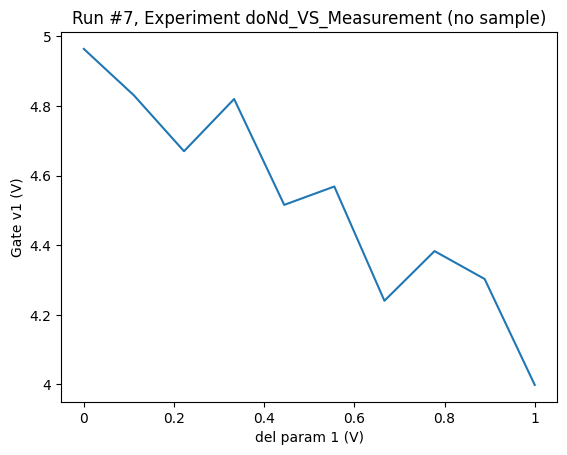

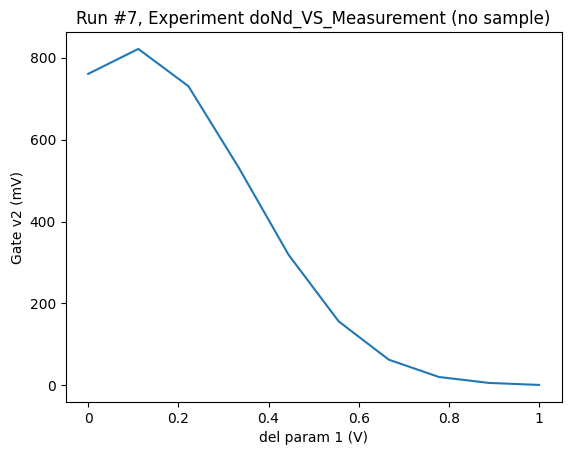

In [11]:
plot_dataset(dataset1)

In [12]:
dataset1.get_parameter_data("dac_ch1")

{'dac_ch1': {'dac_ch1': array([], dtype=float64)}}

In [13]:
dataset1.paramspecs

{'del_param_1': ParamSpec('del_param_1', 'numeric', 'del param 1', 'V', inferred_from=['dac_ch1'], depends_on=[]),
 'dac_ch1': ParamSpec('dac_ch1', 'numeric', 'Gate ch1', 'V', inferred_from=[], depends_on=[]),
 'dmm_v1': ParamSpec('dmm_v1', 'numeric', 'Gate v1', 'V', inferred_from=[], depends_on=['del_param_1']),
 'dmm_v2': ParamSpec('dmm_v2', 'numeric', 'Gate v2', 'V', inferred_from=[], depends_on=['del_param_1'])}

In [14]:
dataset1.get_parameters()

[ParamSpec('del_param_1', 'numeric', 'del param 1', 'V', inferred_from=['dac_ch1'], depends_on=[]),
 ParamSpec('dac_ch1', 'numeric', 'Gate ch1', 'V', inferred_from=[], depends_on=[]),
 ParamSpec('dmm_v1', 'numeric', 'Gate v1', 'V', inferred_from=[], depends_on=['del_param_1']),
 ParamSpec('dmm_v2', 'numeric', 'Gate v2', 'V', inferred_from=[], depends_on=['del_param_1'])]